# 02: Exploratory Data Analysis (EDA) & Preprocessing

## Project: AgroVision
**Purpose:** Analyze the dataset metadata, enforce quality control standards, and prepare the data for training through stratification, normalization, and imbalance handling.

### Key Objectives:
1.  **Data Integrity:** Identify and handle missing values or duplicates.
2.  **Quality Control:** Apply strict resolution (>224px) and aspect ratio filters to remove unsuitable images.
3.  **Class Distribution:** Assess class balance and visualize the dataset structure.
4.  **Stratification:** Generate balanced Train (70%), Validation (10%), and Test (20%) splits.
5.  **Normalization:** Calculate channel-wise Mean and Standard Deviation (on the Train set) for input scaling.
6.  **Imbalance Mitigation:** Compute class weights to penalize errors on minority classes during training.

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

## 1. Data Loading
Initialize paths and load the raw metadata CSV containing file references and labels.

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_PATH / "raw"
PROCESSED_DATA_PATH = DATA_PATH / "processed"
DATASET_CSV_PATH = PROCESSED_DATA_PATH / "dataset.csv"
NORMALIZATION_STATS_PATH = PROCESSED_DATA_PATH / "normalization_stats.json"
CLASS_WEIGHTS_PATH = PROCESSED_DATA_PATH / "class_weights.json"
DATASET_CLEANED_PATH = PROCESSED_DATA_PATH / "dataset_cleaned.csv"

In [3]:
df = pd.read_csv(DATASET_CSV_PATH)
df.head()

,filepath,label
0,fresh_apple\rotated_by_15_Screen Shot 2018-06-...,fresh_apple
1,fresh_apple\rotated_by_15_Screen Shot 2018-06-...,fresh_apple
2,fresh_apple\rotated_by_15_Screen Shot 2018-06-...,fresh_apple
3,fresh_apple\rotated_by_15_Screen Shot 2018-06-...,fresh_apple
4,fresh_apple\rotated_by_15_Screen Shot 2018-06-...,fresh_apple


## 2. Integrity & Quality Assessment
This section validates the dataset's structural integrity and filters out samples that do not meet the minimum quality requirements for a Convolutional Neural Network (CNN).

### Integrity Checks

Check for missing values and duplicates.

In [4]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values: 0
Duplicate rows: 0


### Quality Control Filters
Strict filtering rules are applied to ensure input consistency and prevent model artifacts:

1.  **Resolution Threshold (> 224px):** Images smaller than the network's standard input size (224x224) are discarded. This prevents "upscaling," which introduces blurring and degrades texture details critical for detecting rot.
2.  **Aspect Ratio (0.5 < Ratio < 2.0):** Extreme panoramic or vertical "strip" images are rejected to avoid excessive information loss during center cropping.

In [5]:
df['img_dim'] = [Image.open(RAW_DATA_PATH / path).size for path in df['filepath']]

MIN_SIZE = 224     
MIN_RATIO = 1/2
MAX_RATIO = 2/1    

valid_size = df['img_dim'].apply(lambda x: x[0] >= MIN_SIZE and x[1] >= MIN_SIZE)
valid_ratio = df['img_dim'].apply(lambda x: (x[0] / x[1]) >= MIN_RATIO and (x[0] / x[1]) <= MAX_RATIO)

valid_mask = valid_size & valid_ratio
df_clean = df[valid_mask].copy()
df_rejected = df[~valid_mask].copy()

df_clean.drop(columns=['img_dim'], inplace=True)

print(f"Total original: {len(df)}")
print(f"Kept: {len(df_clean)}")
print(f"Dropped: {len(df_rejected)}")

df = df_clean

Total original: 14682
Kept: 13687
Dropped: 995


## 3. Class Distribution Analysis
The class balance is analyzed to identify potential biases. A severe imbalance may require mitigation strategies such as Class Weighting or Oversampling during training.

In [6]:
print(pd.concat([
    df["label"].value_counts().rename("count"),
    (df["label"].value_counts(normalize=True) * 100).rename("percentage (%)")
], axis=1).sort_index())

                    count  percentage (%)
label                                    
fresh_apple          1376       10.053335
fresh_banana         1475       10.776649
fresh_bitter_gourd    327        2.389128
fresh_capsicum        990        7.233141
fresh_orange         1261        9.213122
fresh_tomato          981        7.167385
stale_apple          2235       16.329364
stale_banana         1402       10.243297
stale_bitter_gourd    357        2.608314
stale_capsicum        901        6.582889
stale_orange         1400       10.228684
stale_tomato          982        7.174691


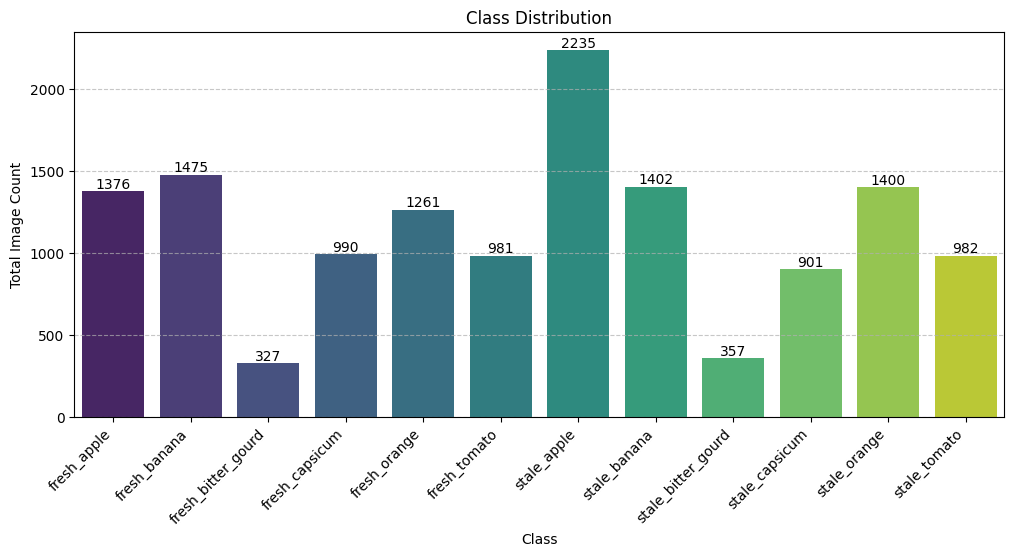

In [7]:
plt.figure(figsize=(12, 5))
label_order = sorted(df["label"].unique())
ax = sns.countplot(data=df, x="label", hue="label", legend=False, palette="viridis", order=label_order)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Total Image Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## 4. Visual Inspection
Random samples from each class are displayed to verify labeling accuracy and image corruption issues before training.

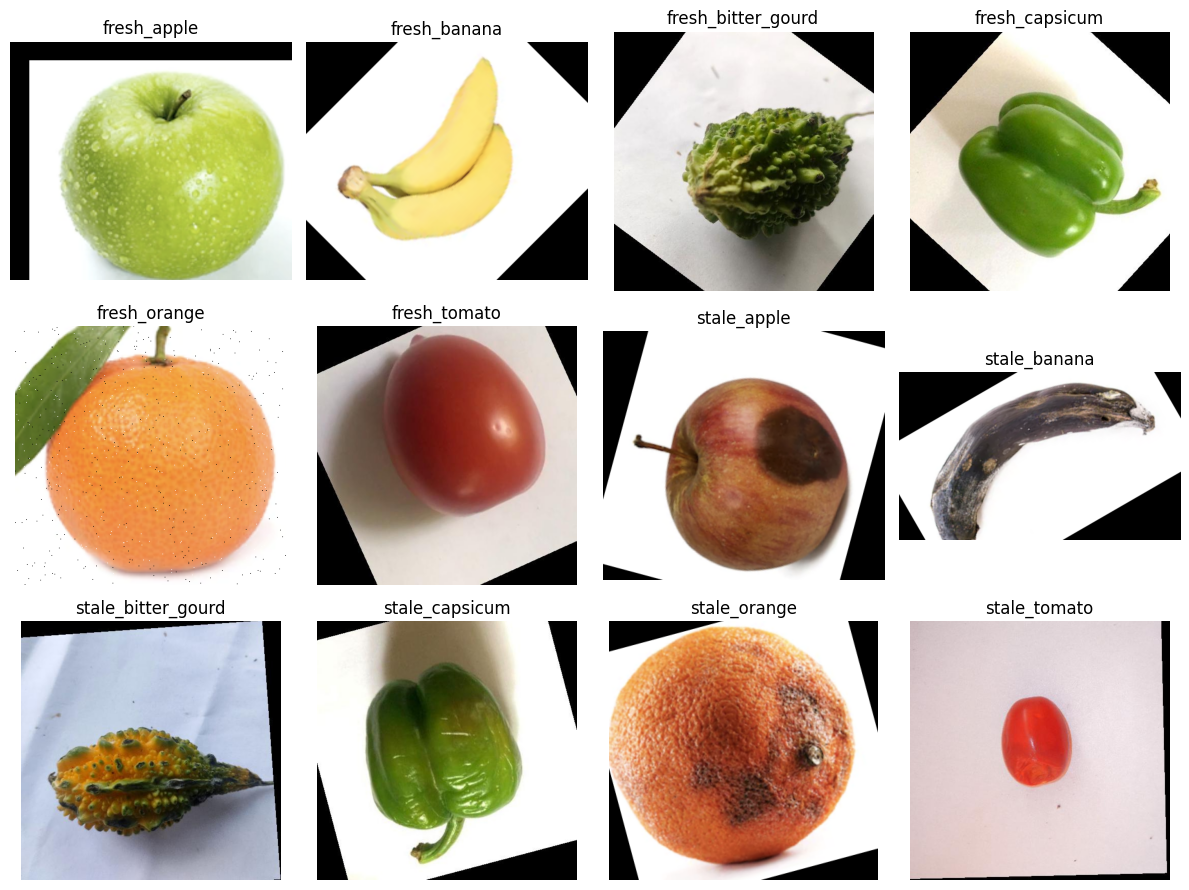

In [8]:
classes = sorted(df['label'].unique())
rows = math.ceil(len(classes) / 4)

plt.figure(figsize=(12, rows * 3))

for i, label in enumerate(classes):
    item = df[df['label'] == label].sample(1).iloc[0]
    
    plt.subplot(rows, 4, i + 1)
    plt.imshow(plt.imread(f"{RAW_DATA_PATH}/{item['filepath']}"))
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Stratified Dataset Splitting
The dataset is divided into **Train (70%)**, **Validation (10%)**, and **Test (20%)** sets.

**Methodology:**
* **Stratified Split:** Ensures that the class distribution remains consistent across all subsets. This prevents the under-representation of minority classes (e.g., `fresh_bitter_gourd`) in the Validation or Test sets, ensuring reliable evaluation metrics.

In [9]:
X = df.index
y = df['label']

train_idx, rest_idx = train_test_split(X, test_size=0.3, stratify=y, random_state=42)
val_idx, test_idx = train_test_split(rest_idx, test_size=2/3, stratify=y[rest_idx], random_state=42)

df.loc[train_idx, 'split'] = 'train'
df.loc[val_idx, 'split'] = 'val'
df.loc[test_idx, 'split'] = 'test'

pd.concat([
    df['split'].value_counts().rename('count'),
    df['split'].value_counts(normalize=True).mul(100).round(2).rename('percentage (%)')
], axis=1)

,count,percentage (%)
split,,
train,9580,69.99
test,2738,20.00
val,1369,10.00


## 6. Normalization Statistics
The channel-wise Mean and Standard Deviation are calculated to normalize inputs during training.

**Important:** These statistics are computed using **only the Training Set**. Excluding Validation and Test data prevents "Data Leakage," ensuring the model evaluation remains unbiased.

In [10]:
train_df = df[df['split'] == 'train']

pixel_sum = np.zeros(3)
pixel_sq_sum = np.zeros(3)
total_pixels = 0

for filepath in train_df['filepath']:
    img_path = RAW_DATA_PATH / filepath
    img = np.array(Image.open(img_path).convert('RGB')) / 255
    pixels = img.reshape(-1, 3)
    pixel_sum += pixels.sum(axis=0)
    pixel_sq_sum += (pixels ** 2).sum(axis=0)
    total_pixels += len(pixels)
        
mean = pixel_sum / total_pixels
std = np.sqrt((pixel_sq_sum / total_pixels) - (mean ** 2))

with open(NORMALIZATION_STATS_PATH, "w") as f:
    json.dump({"mean": mean.tolist(), "std": std.tolist()}, f, indent=4)

print(f"mean = {mean}")
print(f"std  = {std}")

mean = [0.67166198 0.59788906 0.51753235]
std  = [0.33516437 0.34156405 0.3693185 ]


## 7. Class Imbalance Strategy
To address the significant disparity between classes (e.g., `stale_apple` vs. `fresh_bitter_gourd`), class weights are computed using the "balanced" heuristic.

These weights will be incorporated into the Loss Function (CrossEntropy) during training to assign higher penalties to misclassifications of minority classes.

In [11]:
train_labels = df[df['split'] == 'train']['label']
classes = np.unique(train_labels)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)
class_weights_dict = dict(zip(classes, weights, strict=True))

with open(CLASS_WEIGHTS_PATH, "w") as f:
    json.dump(class_weights_dict, f, indent=4)

for cls, weight in class_weights_dict.items():
    print(f"{cls}: {weight:.4f}")

fresh_apple: 0.8290
fresh_banana: 0.7736
fresh_bitter_gourd: 3.4862
fresh_capsicum: 1.1520
fresh_orange: 0.9041
fresh_tomato: 1.1621
stale_apple: 0.5104
stale_banana: 0.8138
stale_bitter_gourd: 3.1933
stale_capsicum: 1.2652
stale_orange: 0.8146
stale_tomato: 1.1621


## 8. Export Processed Data
The processing pipeline is complete. The following artifacts are saved to disk as the "Master Record" for the training phase:

1.  **`dataset_cleaned.csv`**: The filtered and stratified index of images.
2.  **`normalization_stats.json`**: Mean and Std values for input transformation.
3.  **`class_weights.json`**: Weight dictionary for the loss function.

In [12]:
df.to_csv(DATASET_CLEANED_PATH, index=False)

## 9. Summary & Conclusions

The Exploratory Data Analysis (EDA) and preprocessing pipeline have been successfully completed. The `AgroVision` dataset is now fully prepared for the training phase.

**Key Outcomes:**
1.  **Data Hygiene:** The dataset was filtered to remove low-resolution (<224px) and distorted images, ensuring high-quality input for the CNN.
2.  **Stratification:** A precise **70/10/20 split** (Train/Val/Test) was achieved while preserving the original class distribution.
3.  **Normalization:** Channel-wise Mean and Standard Deviation were computed on the training set to standardize inputs.
4.  **Imbalance Mitigation:** Class weights were generated to counteract the disparity between majority classes (e.g., `stale_apple`) and minority classes (e.g., `fresh_bitter_gourd`).

**Next Steps:**
The generated artifacts (`dataset_cleaned.csv`, `normalization_stats.json`, `class_weights.json`) are now ready to be ingested by the training notebook (`03_training.ipynb`).

In [13]:
print(f"Total images processed: {len(df)}")
print(f"Class count: {len(classes)}")
print("-" * 30)
print(f"Train set: {len(df[df['split']=='train'])} images (70%)")
print(f"Val set: {len(df[df['split']=='val'])} images (10%)")
print(f"Test set: {len(df[df['split']=='test'])} images (20%)")
print("-" * 30)
print(f"Artifacts saved to: {PROCESSED_DATA_PATH}")

Total images processed: 13687
Class count: 12
------------------------------
Train set: 9580 images (70%)
Val set: 1369 images (10%)
Test set: 2738 images (20%)
------------------------------
Artifacts saved to: c:\maia\desarrollo_de_soluciones\agrovision\data\processed
